# 03 — v2 Experiment: Sentence Embeddings vs TF-IDF

**Question:** TF-IDF matches words, not meaning. Would dense **sentence embeddings**
(all-MiniLM-L6-v2) — which capture semantics and context — beat the TF-IDF baseline,
especially on the noisy GoEmotions data where bag-of-words struggled (notebook 02)?

**Method:** same six-tone task, held-out evaluation. Three feature/model combos on
two datasets. To give embeddings a *fair* shot, we test both a linear head (LogReg)
and a non-linear one (a small MLP), since a frozen-embedding + linear classifier is
a known-weak configuration.

**Headline finding:** embeddings **did not beat TF-IDF** — on either dataset, with
either head. The non-linear MLP head *narrowed* the gap but never closed it. The
honest conclusion: for this lexically-explicit task, TF-IDF + Logistic Regression is
genuinely the right tool, and the noisy-data bottleneck is the **label scheme**, not
the feature representation.

> Metrics below are recorded from real runs (`python -m src.train_embeddings`).
> Reproduction commands are at the bottom.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. The results matrix (held-out macro-F1)

In [2]:
results = pd.DataFrame({
    "dair-ai (clean)":   {"TF-IDF + LogReg": 0.866, "Embeddings + LogReg": 0.597, "Embeddings + MLP": 0.673},
    "GoEmotions (noisy)":{"TF-IDF + LogReg": 0.409, "Embeddings + LogReg": 0.326, "Embeddings + MLP": 0.366},
})
results

,dair-ai (clean),GoEmotions (noisy)
TF-IDF + LogReg,0.866,0.409
Embeddings + LogReg,0.597,0.326
Embeddings + MLP,0.673,0.366


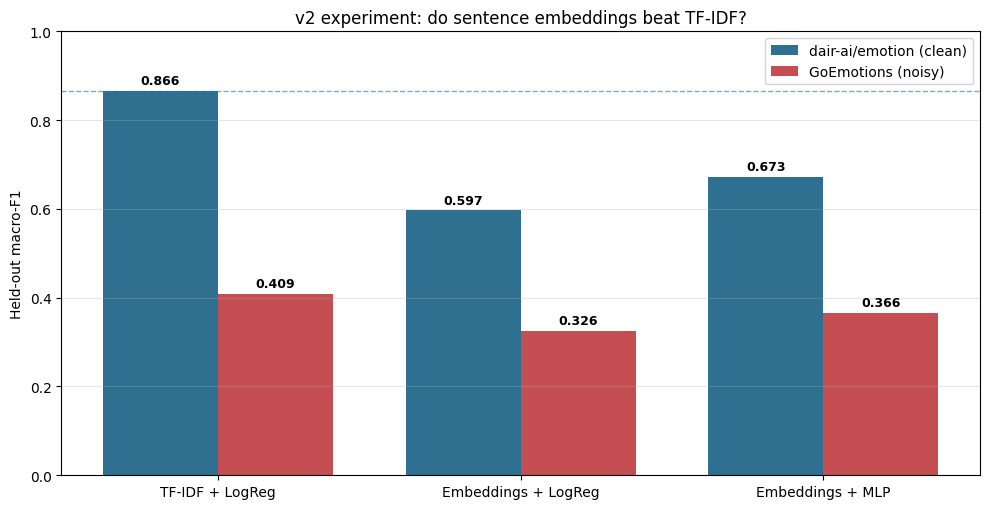

In [3]:
approaches = list(results.index)
x = np.arange(len(approaches)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 5.2))
b1 = ax.bar(x - w/2, results["dair-ai (clean)"],    w, label="dair-ai/emotion (clean)", color="#2f6f8f")
b2 = ax.bar(x + w/2, results["GoEmotions (noisy)"], w, label="GoEmotions (noisy)", color="#c44e52")
ax.axhline(0.866, ls="--", lw=1, color="#2f6f8f", alpha=.6)
ax.set_xticks(x); ax.set_xticklabels(approaches)
ax.set_ylim(0, 1); ax.set_ylabel("Held-out macro-F1")
ax.set_title("v2 experiment: do sentence embeddings beat TF-IDF?")
ax.legend(); ax.grid(axis="y", alpha=.3)
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + .015,
                f"{b.get_height():.3f}", ha="center", fontsize=9, fontweight="bold")
plt.tight_layout(); plt.show()

## 2. Reading the result

**TF-IDF wins on both datasets.** But the nuances are the interesting part:

- **The MLP head helped embeddings** on both datasets (dair-ai 0.597 → 0.673,
  GoEmotions 0.326 → 0.366). So the fair, non-linear test mattered — a linear head
  *understated* what embeddings could do. It still wasn't enough to win.
- **On clean data the gap is large** (0.866 vs 0.673 = 0.19). dair-ai's emotion is
  literally in the words; TF-IDF captures that sharp lexical signal perfectly, and
  compressing to a 384-dim semantic vector throws some of it away.
- **On noisy data the gap shrinks** (0.409 vs 0.366 = 0.04). This is the faint
  signal behind the original hypothesis: embeddings are *relatively* more
  competitive when text is messy. But "relatively closer" is not "better."

Let's make the gap-shrinking explicit:

In [4]:
gap = pd.DataFrame({
    "best embedding model": {"dair-ai (clean)": 0.673, "GoEmotions (noisy)": 0.366},
    "TF-IDF baseline":      {"dair-ai (clean)": 0.866, "GoEmotions (noisy)": 0.409},
})
gap["TF-IDF advantage"] = (gap["TF-IDF baseline"] - gap["best embedding model"]).round(3)
gap

,best embedding model,TF-IDF baseline,TF-IDF advantage
dair-ai (clean),0.673,0.866,0.193
GoEmotions (noisy),0.366,0.409,0.043


## 3. Why embeddings lost — and what would actually help

1. **The task is lexically explicit.** When the label is essentially determined by
   the presence of emotion words, a bag-of-words model is hard to beat. Semantic
   generalization is not the bottleneck here.
2. **The noisy-data problem is the labels, not the features.** On GoEmotions, *both*
   feature types collapse the same way (high recall, precision 0.03–0.34) because of
   the oversized `neutral` grab-bag and `class_weight="balanced"`. A better feature
   representation can't fix a bad label mapping.
3. **Frozen embeddings + a shallow head is the floor, not the ceiling.** The real
   way to make embeddings shine would be **fine-tuning the transformer** on this
   task (not freezing it), or fixing the GoEmotions label scheme — both bigger
   efforts than swapping a feature step.

## 4. Decision

**Keep TF-IDF + Logistic Regression as the production model (macro-F1 0.866).**
This experiment is a *negative result done properly*: hypothesis stated, fair test
run (incl. a non-linear head), result accepted, and the real bottleneck identified.

The embedding code is preserved (`src/embeddings.py`, `src/train_embeddings.py`) so
the fine-tuning follow-up is easy to pick up later.

### Reproduce
```bash
# embeddings, linear head
python -m src.train_embeddings --clf logreg
# embeddings, non-linear head (fair test)
python -m src.train_embeddings --clf mlp
# on GoEmotions: regenerate goemo train/test, then pass --train/--test
```